In [1]:
import sys
sys.path.insert(0, "/home/bausciadaq/BAWSHA/src/instruments/")
from TBS2000B import TBS2000B  # now Python can find it
import time
import h5py
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt


In [2]:

filename = "testYscale.h5"

scope = TBS2000B()
scale =  0.5
desired_rate = int(1e6)
record_length = int(2e5)
navg = 16
scope.set_vertical_scale(1, scale)
scope.set_vertical_scale(2, scale)

with h5py.File(filename, "a") as f:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    groupname = timestamp
    print(scope.query("HOR:RECO?"))
    print(scope.query("WFMOutpre:NR_Pt?"))

    print("Acquiring data...")
    result = scope.acquire_averaged_curve( navg, desired_rate, record_length)
    

    try:
        grp = f.create_group(groupname)
        grp.create_dataset("Time", data=np.array(result["time"]))
        grp.create_dataset("Flux", data=np.array(result["CH1"]))
        grp.create_dataset("Volt", data=np.array(result["CH2"]))
    except:
        print("Something went wrong with Vphi fit...continue")
        pass

    
print("Acquisition Ended!")
del scope

/home/bausciadaq/bawenv/lib/python3.12/site-packages/gpib_ctypes/gpib/gpib.py:54: UserWarning: GPIB library not found. Please manually load it using _load_lib(filename). All GPIB functions will raise OSError until the library is manually loaded.
  warnings.warn(message)


TEKTRONIX,TBS2104B,C033960,CF:91.1CT FV:v1.32.147; FPGA:v2.18;  connected
200000
200000
Acquiring data...
Requested rate:          1000000 S/s
Actual rate:             1333333.33 S/s
Required time scale:     0.013333333333333334 s/div
Actual time scale:       0.01 s/div
Actual record length:    200000.0
Number of (time) divs:   15
Time increment:          8e-07 s
Inverse time increment:  1250000.00 S/s
Acquisition Ended!


(0.001, 0.002)

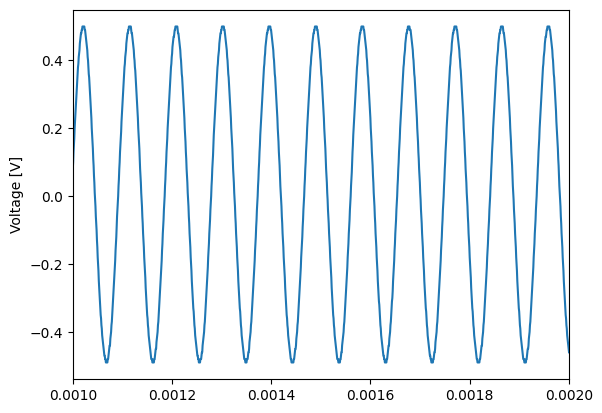

In [3]:
tmin = 1e-3
tmax =2e-3
plt.plot(result["time"],result["CH2"])
plt.ylabel("Voltage [V]")
plt.xlim(tmin, tmax)

In [ ]:
volts1 = yzero + ymult * data
volts2 = (data - yoff) * ymult + yzero

print("Vpp no YOFF :", volts1.max() - volts1.min())
print("Vpp with YOFF:", volts2.max() - volts2.min())